In [3]:
# Required modules
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import time
import torch
import torch.nn as nn
from torch.optim import Adam
import torch.utils.data as Data
from torchvision import transforms
from torchvision.datasets import FashionMNIST
%matplotlib inline

In [ ]:
# To decide whether to use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

cuda
1
Tesla T4


In [5]:
# FashionMNIST data，prepare traing dataset
train_data = FashionMNIST(
    root = './FashionMNIST',
    train = True,
    transform = transforms.ToTensor(),
    download = True
)

# Define a data loader
train_loader = Data.DataLoader(
    dataset = train_data,   # data
    batch_size = 64,    # batch size
    shuffle = False,
    num_workers = 2,
)

# batch No.
print(len(train_loader))

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.3MB/s]

938


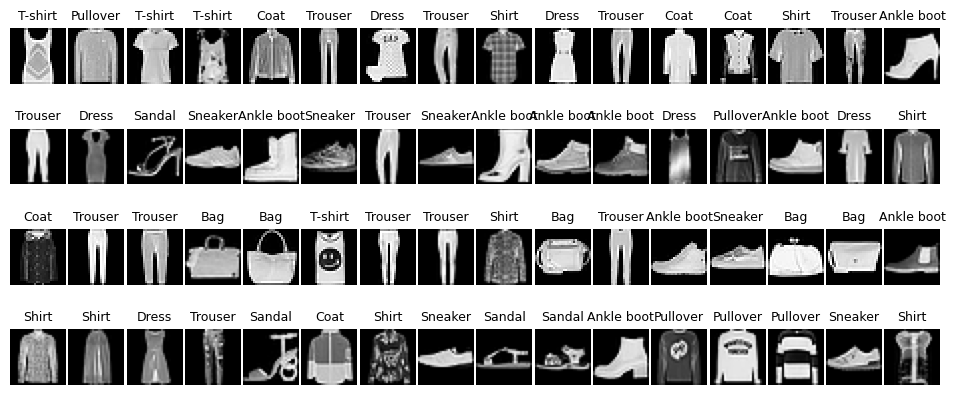

In [6]:
# Obtain data for batches

for step, (b_x, b_y) in enumerate(train_loader):
    if step > 0:
        break

# Visualize images for a batch
batch_x = b_x.squeeze().numpy()
batch_y = b_y.numpy()
label = train_data.classes
label[0] = 'T-shirt'

plt.figure(figsize = (12, 5))
for i in np.arange(len(batch_y)):
    plt.subplot(4, 16, i + 1)
    plt.imshow(batch_x[i, :, :], cmap = plt.cm.gray)
    plt.title(label[batch_y[i]], size = 9)
    plt.axis('off')
    plt.subplots_adjust(wspace = 0.05)

In [8]:
# deal with training data
test_data = FashionMNIST(
    root = './data/FashionMNIST',
    train = False,
    download = True
)

# Add a channel dimention，And the value range is normalized
test_data_x = test_data.data.type(torch.FloatTensor) / 255.0
test_data_x = torch.unsqueeze(test_data_x, dim = 1)
test_data_y = test_data.targets # label of test set

print(test_data_x.shape)
print(test_data_y.shape)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.5MB/s]

torch.Size([10000, 1, 28, 28])
torch.Size([10000])


In [35]:
# define the CNN
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 6, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(6, 16, 5),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Linear(16 * 4 * 4, 120),
            nn.ReLU(),
            nn.Dropout(0.5),      # <--- Added Dropout (3.4)
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Dropout(0.3),      # <--- Added Dropout (3.4)
            nn.Linear(84, 10)
        )

    def forward(self, img):
        feature = self.conv(img)
        output = self.fc(feature.view(img.shape[0], -1))
        return output

In [36]:
mylenet = LeNet().to(device)
from torchsummary import summary
summary(mylenet, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
              ReLU-2            [-1, 6, 24, 24]               0
         MaxPool2d-3            [-1, 6, 12, 12]               0
            Conv2d-4             [-1, 16, 8, 8]           2,416
              ReLU-5             [-1, 16, 8, 8]               0
         MaxPool2d-6             [-1, 16, 4, 4]               0
            Linear-7                  [-1, 120]          30,840
              ReLU-8                  [-1, 120]               0
           Dropout-9                  [-1, 120]               0
           Linear-10                   [-1, 84]          10,164
             ReLU-11                   [-1, 84]               0
          Dropout-12                   [-1, 84]               0
           Linear-13                   [-1, 10]             850
Total params: 44,426
Trainable params: 

In [41]:
def train_model(model, traindataloader, train_rate, criterion, optimizer, num_epochs=25, patience=5):
    batch_num = len(traindataloader)
    train_batch_num = round(batch_num * train_rate)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    counter = 0

    train_loss_all, val_loss_all = [], []
    train_acc_all, val_acc_all = [], [] # List is defined here

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        model.train()
        train_loss, train_corrects, train_num = 0.0, 0, 0
        val_loss, val_corrects, val_num = 0.0, 0, 0

        for step, (b_x, b_y) in enumerate(traindataloader):
            b_x, b_y = b_x.to(device), b_y.to(device)
            if step < train_batch_num:
                output = model(b_x)
                loss = criterion(output, b_y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                train_loss += loss.item() * b_x.size(0)
                train_corrects += torch.sum(torch.argmax(output, 1) == b_y)
                train_num += b_x.size(0)
            else:
                model.eval()
                with torch.no_grad():
                    output = model(b_x)
                    loss = criterion(output, b_y)
                    val_loss += loss.item() * b_x.size(0)
                    val_corrects += torch.sum(torch.argmax(output, 1) == b_y)
                    val_num += b_x.size(0)

        # --- FIX 1: Record Training Accuracy here ---
        train_loss_all.append(train_loss / train_num)
        train_acc_all.append(train_corrects.double().item() / train_num)

        val_loss_all.append(val_loss / val_num)
        val_acc_all.append(val_corrects.double().item() / val_num)

        print(f'Val Loss: {val_loss_all[-1]:.4f} Val Acc: {val_acc_all[-1]:.4f}')

        if val_loss_all[-1] < best_loss:
            best_loss = val_loss_all[-1]
            best_model_wts = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    model.load_state_dict(best_model_wts)

    # --- FIX 2: Include 'train_acc_all' in the returned DataFrame ---
    return model, pd.DataFrame({
        'epoch': range(len(train_loss_all)),
        'train_loss_all': train_loss_all,
        'train_acc_all': train_acc_all, # Added this
        'val_loss_all': val_loss_all,
        'val_acc_all': val_acc_all
    })

In [42]:
# Training
optimizer = Adam(mylenet.parameters(), lr=0.001, weight_decay=1e-4) # Added weight_decay
criterion = nn.CrossEntropyLoss() # Added CrossEntropyLoss for classification

myconvnet, train_process = train_model(mylenet, train_loader, 0.8, criterion, optimizer, num_epochs = 25)

Epoch 0/24
Val Loss: 0.3065 Val Acc: 0.8892
Epoch 1/24
Val Loss: 0.2976 Val Acc: 0.8917
Epoch 2/24
Val Loss: 0.2983 Val Acc: 0.8907
Epoch 3/24
Val Loss: 0.2979 Val Acc: 0.8922
Epoch 4/24
Val Loss: 0.3040 Val Acc: 0.8911
Epoch 5/24
Val Loss: 0.3014 Val Acc: 0.8919
Epoch 6/24
Val Loss: 0.2972 Val Acc: 0.8934
Epoch 7/24
Val Loss: 0.2922 Val Acc: 0.8927
Epoch 8/24
Val Loss: 0.2921 Val Acc: 0.8937
Epoch 9/24
Val Loss: 0.2949 Val Acc: 0.8935
Epoch 10/24
Val Loss: 0.3027 Val Acc: 0.8957
Epoch 11/24
Val Loss: 0.2991 Val Acc: 0.8928
Epoch 12/24
Val Loss: 0.2936 Val Acc: 0.8932
Epoch 13/24
Val Loss: 0.2937 Val Acc: 0.8938
Early stopping triggered at epoch 13


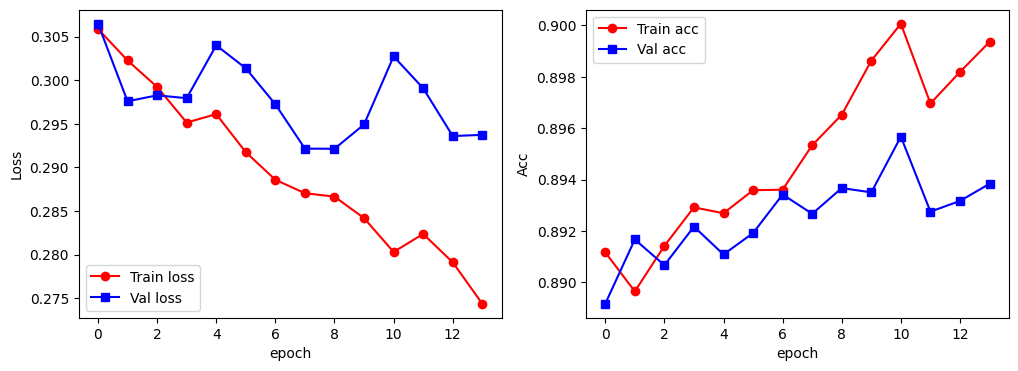

In [43]:
# Visualize the training process
plt.figure(figsize = (12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_process.epoch, train_process.train_loss_all, 'ro-', label = 'Train loss')
plt.plot(train_process.epoch, train_process.val_loss_all, 'bs-', label = 'Val loss')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_process.epoch, train_process.train_acc_all, 'ro-', label = 'Train acc')
plt.plot(train_process.epoch, train_process.val_acc_all, 'bs-', label = 'Val acc')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('Acc')

plt.show()

In [44]:
# Test set predictions and visualize predictions
mylenet.eval()
output = mylenet(test_data_x.to(device))
pre_lab = torch.argmax(output, 1)
acc = accuracy_score(test_data_y, pre_lab.cpu())
print(test_data_y)
print(pre_lab)
print('The prediction accuracy on the test set is', acc)

tensor([9, 2, 1,  ..., 8, 1, 5])
tensor([9, 2, 1,  ..., 8, 1, 5], device='cuda:0')
The prediction accuracy on the test set is 0.8933


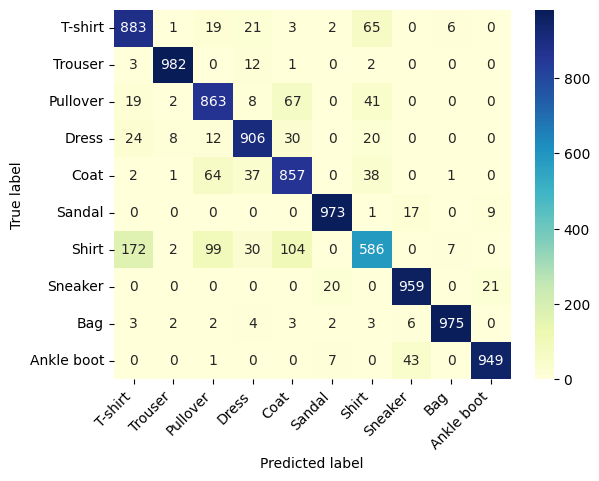

In [45]:
# Calculate and visualize the confusion matrix on the test set
conf_mat = confusion_matrix(test_data_y, pre_lab.cpu())
df_cm = pd.DataFrame(conf_mat, index = label, columns = label)
heatmap = sns.heatmap(df_cm, annot = True, fmt = 'd', cmap = 'YlGnBu')
heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation = 0, ha = 'right')
heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation = 45, ha = 'right')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()